In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [2]:
!pip install dagshub
!pip install mlflow
import mlflow
import mlflow.sklearn
import dagshub
import warnings
import json
import time
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 12.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 6.5 MB/s eta 0:00:00
  Attempting uninstall: dacite
    Found existing installation: dacite 1.9.2
    Uninstalling dacite-1.9.2:
      Successfully uninstalled dacite-1.9.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ydata-profiling 4.18.1 requires dacite<2,>=1.9, but you have dacite 1.6.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 2.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━

In [3]:
dagshub.init(repo_owner='akave23', repo_name='IEEE-CIS-Fraud-Detection-ML2', mlflow=True)
mlflow.set_experiment('RandomForest_Training_v1')

print('Setup complete!')
print(f'MLflow URI: {mlflow.get_tracking_uri()}')

❗❗❗ AUTHORIZATION REQUIRED ❗❗❗

Output()



Open the following link in your browser to authorize the client:
https://dagshub.com/login/oauth/authorize?state=25d4cf94-1764-4e48-82b6-86ff6e448a8c&client_id=32b60ba385aa7cecf24046d8195a71c07dd345d9657977863b52e7748e0f0f28&middleman_request_id=55f35d4da2131a7c101674ec007a8d481cb98a8e905bb2f30d617364d2d2c1d4




Accessing as akave23

Initialized MLflow to track repo "akave23/IEEE-CIS-Fraud-Detection-ML2"

Repository akave23/IEEE-CIS-Fraud-Detection-ML2 initialized!

Setup complete!
MLflow URI: https://dagshub.com/akave23/IEEE-CIS-Fraud-Detection-ML2.mlflow


In [4]:
train = pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv").merge(
    pd.read_csv("/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv"),
    on='TransactionID',
    how='left'
)

# Target
y = train['isFraud'].values

# Features (remove target column)
X = train.drop('isFraud', axis=1)
X= X.drop('TransactionID', axis=1)

from sklearn.model_selection import train_test_split


X_train, X_valid, y_train, y_valid = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



In [5]:
X.head()
print(f'Class balance: Normal={np.sum(y==0):,} | Fraud={np.sum(y==1):,}')
print(np.sum(y==1)/(np.sum(y==0) + np.sum(y==1)))

Class balance: Normal=569,877 | Fraud=20,663
0.03499000914417313


## **Data CleanUp**

In [6]:
#with mlflow.start_run(run_name='RandomForest_Cleaning'):
#remove high NaN columns(>90%)
X_tr  = X_train.reset_index(drop=True).copy()
X_val = X_valid.reset_index(drop=True).copy()

nan_pct       = X_tr.isnull().mean()          
high_nan_cols = nan_pct[nan_pct > 0.90].index.tolist()

X_tr.drop(columns=high_nan_cols, inplace=True)
X_val.drop(columns=[c for c in high_nan_cols if c in X_val.columns], inplace=True)

print(f'\nSTEP 1 | High-NaN removed (>90%, counted on X_tr): {len(high_nan_cols)}')

#create new columns for each column which had any NaN values 
missing_cols = [c for c in X_tr.columns if X_tr[c].isnull().any()]  

for col in missing_cols:
    nan_flag = col + '_was_nan'
    X_tr[nan_flag]  = X_tr[col].isnull().astype(np.int8)
    X_val[nan_flag] = X_val[col].isnull().astype(np.int8) if col in X_val.columns else 0


print(f'STEP 2 | Missing indicators added: {len(missing_cols)}')

#categorical columns
cat_cols  = X_tr.select_dtypes(include='object').columns.tolist()
high_card = [c for c in cat_cols if X_tr[c].nunique() > 50]
low_card  = [c for c in cat_cols if X_tr[c].nunique() <= 50]

# Frequency Encoding — train frequencies only
freq_maps = {}
for col in high_card:
    freq_maps[col] = X_tr[col].value_counts(normalize=True).to_dict()  # ← X_tr-ზე!
    for df in [X_tr, X_val]:
        df[col] = df[col].map(freq_maps[col]).fillna(0.0)

# Label Encoding — fit on train+test vocab (unseen labels-ისთვის)
label_encoders = {}
for col in low_card:
    le = LabelEncoder()
    # vocab: train + val + test — unseen label error-ის თავიდან ასაცილებლად
    vocab = pd.concat([X_tr[col], X_val[col]], axis=0).astype(str)
    le.fit(vocab)
    label_encoders[col] = le
    for df in [X_tr, X_val]:
        df[col] = le.transform(df[col].astype(str))

print(f'STEP 3 | Freq encoded: {len(high_card)} | Label encoded: {len(low_card)}')




# median imputation
nan_counts_before = {
    col: int(X_tr[col].isnull().sum())
    for col in missing_cols if col in X_tr.columns
}

imputer   = SimpleImputer(strategy='median')
col_names = X_tr.columns.tolist()

X_tr_arr   = imputer.fit_transform(X_tr)    # ← fit + transform X_tr
X_val_arr  = imputer.transform(X_val)        # ← transform only (X_tr medians)

X_tr   = pd.DataFrame(X_tr_arr,   columns=col_names)
X_val  = pd.DataFrame(X_val_arr,  columns=col_names)

print(f'STEP 4 | Median Imputation (fit on X_tr only)')
print(f'  NaN in X_tr  after: {X_tr.isnull().sum().sum()}')
print(f'  NaN in X_val after: {X_val.isnull().sum().sum()}')


#outlier clipping
skip_cap  = [c for c in X_tr.columns if c.endswith('_was_nan') or c == 'TransactionDT']
cap_cols  = [c for c in X_tr.select_dtypes(include=np.number).columns if c not in skip_cap]

cap_bounds   = {}
capped_cols  = []
capped_pcts  = []

for col in cap_cols:
    lo = X_tr[col].quantile(0.01)   # ← X_tr-ზე!
    hi = X_tr[col].quantile(0.99)   # ← X_tr-ზე!
    n_out = int(((X_tr[col] < lo) | (X_tr[col] > hi)).sum())
    if n_out > 0:
        cap_bounds[col] = (lo, hi)
        capped_cols.append(col)
        capped_pcts.append(n_out / len(X_tr) * 100)
        for df in [X_tr, X_val]:
            df[col] = df[col].clip(lo, hi)   # ← train bounds ყველგან!

print(f'STEP 5 | Outlier capping (fit on X_tr): {len(capped_cols)} cols')

#high correlation removal
corr_matrix = X_tr.select_dtypes(include=np.number).corr().abs()
upper       = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr   = [c for c in upper.columns if any(upper[c] > 0.95)]

for df in [X_tr, X_val]:
    df.drop(columns=[c for c in high_corr if c in df.columns], inplace=True)

    print(f'STEP 6 | High-corr removed (>0.95): {len(high_corr)}')

# STEP 7: Low-Variance columns removal. threshold 0.01

variances = X_tr.var()                       
low_var_cols = variances[variances < 0.01].index.tolist()

for df in [X_tr, X_val]:
    df.drop(columns=[c for c in low_var_cols if c in df.columns], inplace=True)

print(f'STEP 7 | Low-variance removed : {len(low_var_cols)}')

#mlflow run
n_high_nan   = len(high_nan_cols)
n_low_var    = len(low_var_cols)
n_indicators = len(missing_cols)
n_final      = X_tr.shape[1]

#mlflow.log_param('val_size', 0.20)
#mlflow.log_param('split_stratified', True)
#mlflow.log_param('nan_threshold', 0.90)
# mlflow.log_param('imputation', 'median')
# mlflow.log_param('outlier_cap', '1pct-99pct')
# mlflow.log_param('corr_threshold', 0.95)
# mlflow.log_param('high_card_encoding', 'frequency')
# mlflow.log_param('low_card_encoding', 'label')

# mlflow.log_metric('train_size',          len(X_tr))
#mlflow.log_metric('val_size_rows',       len(X_val))

#mlflow.log_metric('removed_high_nan',    n_high_nan)
# mlflow.log_metric('added_nan_indicators', n_indicators)
# mlflow.log_metric('removed_low_var',     n_low_var)
# mlflow.log_metric('capped_columns',      len(capped_cols))
#mlflow.log_metric('final_n_features',    n_final)




STEP 1 | High-NaN removed (>90%, counted on X_tr): 12
STEP 2 | Missing indicators added: 402
STEP 3 | Freq encoded: 6 | Label encoded: 23
STEP 4 | Median Imputation (fit on X_tr only)
  NaN in X_tr  after: 0
  NaN in X_val after: 0
STEP 5 | Outlier capping (fit on X_tr): 393 cols
STEP 6 | High-corr removed (>0.95): 463
STEP 6 | High-corr removed (>0.95): 463
STEP 7 | Low-variance removed : 58


## **Feature Engineering**

In [7]:
#with mlflow.start_run(run_name='RandomForest_Feature_Engineering'):

n_before = X_tr.shape[1]

# Time features
if 'TransactionDT' in X_tr.columns:
    for df in [X_tr, X_val]:
        df['hour_of_day']  = (df['TransactionDT'] // 3600) % 24
        df['day_of_week']  = (df['TransactionDT'] // 86400) % 7
        df['day_of_month'] = (df['TransactionDT'] // 86400) % 30
        df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
        df['is_night']     = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] <= 5)).astype(int)

# Amount features
if 'TransactionAmt' in X_tr.columns:
    for df in [X_tr, X_val]:
        df['amt_log']      = np.log1p(df['TransactionAmt'])
        df['amt_decimal']  = df['TransactionAmt'] % 1
        df['amt_is_round'] = (df['TransactionAmt'] % 1 < 0.01).astype(int)

# card1 aggregation — fit stats on X_tr only, map to X_val
if 'card1' in X_tr.columns and 'TransactionAmt' in X_tr.columns:
    card1_stats = X_tr.groupby('card1')['TransactionAmt'].agg(
        card1_mean='mean', card1_count='count').reset_index()
    X_tr  = X_tr.merge(card1_stats,  on='card1', how='left')
    X_val = X_val.merge(card1_stats, on='card1', how='left')
    for col in ['card1_mean', 'card1_count']:
        med = X_tr[col].median()
        for df in [X_tr, X_val]:
            df[col].fillna(med, inplace=True)

n_after = X_tr.shape[1]

assert X_tr.shape[0]  == len(y_train)
assert X_val.shape[0] == len(y_valid)

print(f'Features: {n_before} -> {n_after}  (+{n_after - n_before} new)')
print(f'X_tr: {X_tr.shape} | y_train: {y_train.shape}')

# mlflow.log_metric('features_before_fe', n_before)
# mlflow.log_metric('features_after_fe',  n_after)
# mlflow.log_metric('new_features',        n_after - n_before)

Features: 301 -> 311  (+10 new)
X_tr: (472432, 311) | y_train: (472432,)


## **Feature Selection**

=== Method A: RF Gini Importance ===
  Selected: 279 / 311 | Val AUC = 0.8827


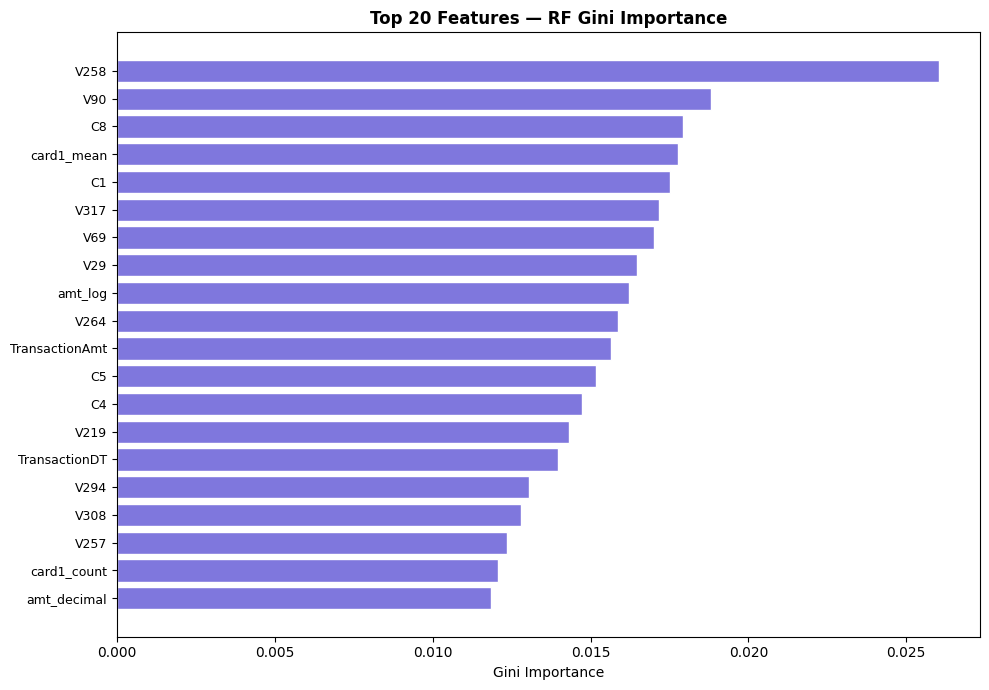


=== Method C: RFE ===
Fitting estimator with 279 features.
Fitting estimator with 269 features.
Fitting estimator with 259 features.
Fitting estimator with 249 features.
Fitting estimator with 239 features.
Fitting estimator with 229 features.
Fitting estimator with 219 features.
Fitting estimator with 209 features.
Fitting estimator with 199 features.
Fitting estimator with 189 features.
Fitting estimator with 179 features.
Fitting estimator with 169 features.
Fitting estimator with 159 features.
Fitting estimator with 149 features.
Fitting estimator with 139 features.
Fitting estimator with 129 features.
  Selected: 120 / 311 | Val AUC = 0.8850

=== Feature Selection Comparison ===
              method  n_features  val_auc
   C: RFE (120 feat)         120 0.885016
A: Gini (bottom 10%)         279 0.882693


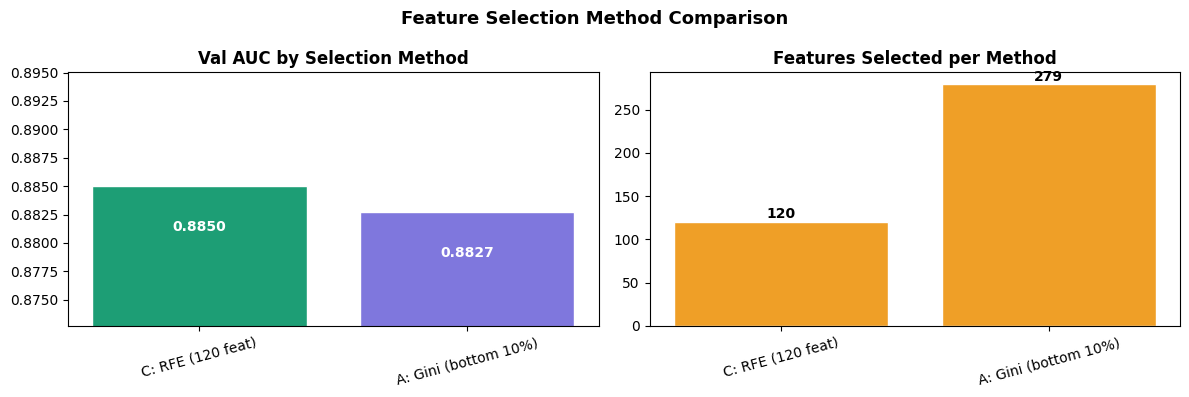


Final features: 120  (best method: C: RFE (120 feat))
X_tr_sel: (472432, 120) | X_val_sel: (118108, 120)


In [8]:
#with mlflow.start_run(run_name='RandomForest_Feature_Selection'):

feature_names = X_tr.columns.tolist()
n_total       = len(feature_names)

# ── Method A: Gini Importance
print('=== Method A: RF Gini Importance ===')
rf_fs = RandomForestClassifier(
    n_estimators=150, max_depth=15, min_samples_leaf=10,
    class_weight='balanced', n_jobs=-1, random_state=42)
rf_fs.fit(X_tr.values, y_train)

importances = pd.Series(rf_fs.feature_importances_, index=feature_names).sort_values(ascending=False)
thr_a       = importances.quantile(0.10)
by_gini     = importances[importances > thr_a].index.tolist()

rf_tmp = RandomForestClassifier(
    n_estimators=100, max_depth=10, class_weight='balanced', n_jobs=-1, random_state=42)
rf_tmp.fit(X_tr[by_gini].values, y_train)
auc_gini = roc_auc_score(y_valid, rf_tmp.predict_proba(X_val[by_gini].values)[:, 1])
print(f'  Selected: {len(by_gini)} / {n_total} | Val AUC = {auc_gini:.4f}')




fig, ax = plt.subplots(figsize=(10, 7))
top20_imp = importances.head(20)
ax.barh(range(len(top20_imp)), top20_imp.values, color='#7F77DD', edgecolor='white')
ax.set_yticks(range(len(top20_imp)))
ax.set_yticklabels(top20_imp.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Gini Importance')
ax.set_title('Top 20 Features — RF Gini Importance', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()



# ── Method B: RFE ─────────────────────────────────────────
print('\n=== Method C: RFE ===')
rfe = RFE(
    estimator=RandomForestClassifier(
        n_estimators=50, max_depth=10, n_jobs=-1, random_state=42),
    n_features_to_select=min(120, len(by_gini)),
    step=10, verbose=1)
rfe.fit(X_tr[by_gini].values, y_train)
by_rfe = [f for f, keep in zip(by_gini, rfe.support_) if keep]

rf_tmp.fit(X_tr[by_rfe].values, y_train)
auc_rfe = roc_auc_score(y_valid, rf_tmp.predict_proba(X_val[by_rfe].values)[:, 1])
print(f'  Selected: {len(by_rfe)} / {n_total} | Val AUC = {auc_rfe:.4f}')



sel_results = [
    {'method': 'A: Gini (bottom 10%)', 'n_features': len(by_gini), 'val_auc': auc_gini},
    {'method': 'C: RFE (120 feat)',    'n_features': len(by_rfe),  'val_auc': auc_rfe},
]
sel_df = pd.DataFrame(sel_results).sort_values('val_auc', ascending=False)
print('\n=== Feature Selection Comparison ===')
print(sel_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors_sel = ['#1D9E75' if i == 0 else '#7F77DD' for i in range(len(sel_df))]

axes[0].bar(sel_df['method'], sel_df['val_auc'], color=colors_sel, edgecolor='white')
for i, (_, row) in enumerate(sel_df.iterrows()):
    axes[0].text(i, row['val_auc']-0.003, f"{row['val_auc']:.4f}",
                 ha='center', va='top', fontsize=10, fontweight='bold', color='white')
axes[0].set_ylim(min(sel_df['val_auc'])-0.01, max(sel_df['val_auc'])+0.01)
axes[0].set_title('Val AUC by Selection Method', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

axes[1].bar(sel_df['method'], sel_df['n_features'], color='#EF9F27', edgecolor='white')
for i, (_, row) in enumerate(sel_df.iterrows()):
    axes[1].text(i, row['n_features']+1, str(row['n_features']),
                 ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[1].set_title('Features Selected per Method', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Feature Selection Method Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('chart7_feature_selection.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Pick best method & build final feature sets ────────────
best_sel = sel_df.iloc[0]['method']
if 'Gini' in best_sel:
    FINAL_FEATURES = by_gini
else:
    FINAL_FEATURES = by_rfe

X_tr_sel  = X_tr[FINAL_FEATURES].copy()
X_val_sel = X_val[FINAL_FEATURES].copy()

with open('rf_selected_features.json', 'w') as f:
    json.dump(FINAL_FEATURES, f)

#mlflow.log_metric('features_total',     n_total)
#mlflow.log_metric('features_gini',      len(by_gini))

#  mlflow.log_metric('features_rfe',       len(by_rfe))
#  mlflow.log_metric('features_final',     len(FINAL_FEATURES))
# mlflow.log_metric('val_auc_gini',       auc_gini)

#  mlflow.log_metric('val_auc_rfe',        auc_rfe)
#  mlflow.log_artifact('rf_feature_importance.png')
# mlflow.log_artifact('chart7_feature_selection.png')
#  mlflow.log_artifact('rf_selected_features.json')

print(f'\nFinal features: {len(FINAL_FEATURES)}  (best method: {best_sel})')
print(f'X_tr_sel: {X_tr_sel.shape} | X_val_sel: {X_val_sel.shape}')

## **Training**

In [9]:
def run_cv(X_features, y_target, model_params, n_splits=5):
    X_arr = X_features.values if hasattr(X_features, 'values') else X_features
    skf   = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    oof   = np.zeros(len(y_target))
    cv_aucs, tr_aucs = [], []
    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_arr, y_target)):
        X_tr_f, X_v_f = X_arr[tr_idx], X_arr[val_idx]
        y_tr_f, y_v_f = y_target[tr_idx], y_target[val_idx]
        rf = RandomForestClassifier(**model_params)
        rf.fit(X_tr_f, y_tr_f)
        oof[val_idx] = rf.predict_proba(X_v_f)[:, 1]
        cv_aucs.append(roc_auc_score(y_v_f,  oof[val_idx]))
        tr_aucs.append(roc_auc_score(y_tr_f, rf.predict_proba(X_tr_f)[:, 1]))
        print(f'  Fold {fold+1}: Val={cv_aucs[-1]:.4f} | Train={tr_aucs[-1]:.4f} | Gap={tr_aucs[-1]-cv_aucs[-1]:.4f}')
    return cv_aucs, tr_aucs, oof

print(f'CV helper ready.')
print(f'Training: X_tr_sel={X_tr_sel.shape} | y_train={y_train.shape}')

CV helper ready.
Training: X_tr_sel=(472432, 120) | y_train=(472432,)


In [10]:
# Overfitting demo
#with mlflow.start_run(run_name='RF_Overfit_Demo'):
#    params = {'n_estimators':300,'max_depth':None,'min_samples_leaf':1,
 #             'max_features':'sqrt','class_weight':'balanced','n_jobs':-1,'random_state':42}
  #  cv, tr, _ = run_cv(X_tr_sel, y_train, params)
   # gap = np.mean(tr) - np.mean(cv)
    #print(f'\nOVERFITTING: Train={np.mean(tr):.4f} | Val={np.mean(cv):.4f} | Gap={gap:.4f}')
 #
  #  for k, v in params.items(): mlflow.log_param(k, str(v))
   # mlflow.log_metric('auc_cv_mean',    np.mean(cv))
  #  mlflow.log_metric('auc_train_avg',  np.mean(tr))
  #  mlflow.log_metric('overfitting_gap', gap)
   # mlflow.set_tag('status', 'OVERFITTING')

In [11]:
# Underfitting demo
#with mlflow.start_run(run_name='RF_Underfit_Demo'):
 #   params = {'n_estimators':100,'max_depth':3,'min_samples_leaf':100,
  #            'max_features':'sqrt','class_weight':'balanced','n_jobs':-1,'random_state':42}
   # cv, tr, _ = run_cv(X_tr_sel, y_train, params)
    #gap = np.mean(tr) - np.mean(cv)
    #print(f'\nUNDERFITTING: Train={np.mean(tr):.4f} | Val={np.mean(cv):.4f} | Gap={gap:.4f}')
 #
  #  for k, v in params.items(): mlflow.log_param(k, str(v))
   # mlflow.log_metric('auc_cv_mean',    np.mean(cv))
    #mlflow.log_metric('auc_train_avg',  np.mean(tr))
    #mlflow.log_metric('overfitting_gap', gap)
    #mlflow.set_tag('status', 'UNDERFITTING')

In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

configs = [
    ('RF_depth6_leaf30',  6, 30, 200, 'sqrt'),
    ('RF_depth10_leaf20', 10, 20, 150, 'sqrt'),
    ('RF_depth12_leaf15', 12, 15, 200, 'sqrt'),
    ('RF_depth15_leaf10', 15, 10, 200, 'sqrt'),
]

grid_results = []

for name, max_d, min_l, n_est, max_feat in configs:
    p = {
        'n_estimators': n_est,
        'max_depth': max_d,
        'min_samples_leaf': min_l,
        'max_features': max_feat,
        'class_weight': 'balanced',
        'n_jobs': -1,
        'random_state': 42
    }

 #   with mlflow.start_run(run_name=name):
        print(f'\n{name}')

        cv, tr, oof = run_cv(X_tr_sel, y_train, p)

        cv_m  = np.mean(cv)
        tr_m  = np.mean(tr)
        gap   = tr_m - cv_m

        # OOF PR-AUC
        oof_pr = average_precision_score(y_train, oof)

        # Train model on full train
        rf_g = RandomForestClassifier(**p)
        rf_g.fit(X_tr_sel.values, y_train)

        val_probs = rf_g.predict_proba(X_val_sel.values)[:, 1]

        val_roc = roc_auc_score(y_valid, val_probs)
        val_pr  = average_precision_score(y_valid, val_probs)

        status = (
            'OVERFITTING' if gap > 0.05
            else 'UNDERFITTING' if cv_m < 0.5   # PR-AUC scale fix
            else 'OK'
        )

        print(f'  CV PR-AUC={cv_m:.4f} | Train={tr_m:.4f} | Gap={gap:.4f}')
        print(f'  Val PR-AUC={val_pr:.4f} | ROC-AUC={val_roc:.4f} [{status}]')

     
 #       for k, v in p.items():
 #           mlflow.log_param(k, str(v))

    #    mlflow.log_metric('pr_auc_cv_mean',     cv_m)
     #   mlflow.log_metric('pr_auc_train_avg',   tr_m)
     #   mlflow.log_metric('pr_auc_oof',         oof_pr)
     #   mlflow.log_metric('pr_auc_val_holdout', val_pr)

      #  mlflow.log_metric('roc_auc_val',        val_roc)  

     #   mlflow.log_metric('overfitting_gap', gap)
     #   mlflow.set_tag('status', status)

        grid_results.append({
            'config': name,
            'pr_auc_cv': cv_m,
            'pr_auc_val': val_pr,
            'roc_auc_val': val_roc,
            'gap': gap,
            'status': status
        })

# Sort by PR-AUC (IMPORTANT)
res_df = pd.DataFrame(grid_results).sort_values('pr_auc_val', ascending=False)

print('\n=== Grid Search Results (PR-AUC) ===')
print(res_df.to_string(index=False))

# ── Plot (PR-AUC now) ─────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
x_pos = np.arange(len(res_df))

ax.bar(x_pos-0.2, res_df['pr_auc_cv'],  width=0.35,
       label='CV PR-AUC', color='#7F77DD', edgecolor='white')

ax.bar(x_pos+0.2, res_df['pr_auc_val'], width=0.35,
       label='HeldOut PR-AUC', color='#1D9E75', edgecolor='white')

ax.set_xticks(x_pos)
ax.set_xticklabels(res_df['config'], rotation=30, ha='right', fontsize=9)

ax.set_ylim(min(res_df['pr_auc_val'])-0.01, max(res_df['pr_auc_val'])+0.02)

ax.set_ylabel('PR-AUC')
ax.set_title('Grid Search — PR-AUC (Imbalanced Focus)', fontsize=12, fontweight='bold')

ax.legend(fontsize=10)

plt.tight_layout()
plt.savefig('chart8_grid_search.png', dpi=130, bbox_inches='tight')
plt.show()

## **FINAL MODEL PIPELINE**

In [ ]:
from sklearn.metrics import average_precision_score, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

FINAL_PARAMS = {
    'n_estimators': 250, 'max_depth': 15, 'min_samples_leaf': 20,
    'max_features': 'sqrt', 'class_weight': 'balanced',
    'oob_score': True, 'n_jobs': -1, 'random_state': 42
}

with mlflow.start_run(run_name='RandomForest_Final') as run:

    print(f'Final training: X_tr_sel={X_tr_sel.shape} | y_train={y_train.shape}')

    cv_prs, tr_prs, oof_preds = run_cv(X_tr_sel, y_train, FINAL_PARAMS, n_splits=5)

    oof_pr  = average_precision_score(y_train, oof_preds)
    cv_m    = np.mean(cv_prs)
    tr_m    = np.mean(tr_prs)
    gap     = tr_m - cv_m

    final_rf = RandomForestClassifier(**FINAL_PARAMS)
    final_rf.fit(X_tr_sel.values, y_train)

    val_preds = final_rf.predict_proba(X_val_sel.values)[:, 1]
    val_pr    = average_precision_score(y_valid, val_preds)

    status = (
        'OVERFITTING' if gap > 0.05
        else 'UNDERFITTING' if cv_m < 0.5
        else 'OK'
    )

    print(f'\nOOF PR-AUC     : {oof_pr:.4f}')
    print(f'CV  PR-AUC     : {cv_m:.4f} ± {np.std(cv_prs):.4f}')
    print(f'Train PR-AUC   : {tr_m:.4f}  | Gap: {gap:.4f}')
    print(f'HeldOut PR-AUC : {val_pr:.4f}')
    print(f'OOB Score      : {final_rf.oob_score_:.4f}')
    print(f'Status         : {status}')

    # Confusion matrix (threshold still 0.5 — optional to tune later)
    cm = confusion_matrix(y_valid, (val_preds >= 0.5).astype(int))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Pred Normal','Pred Fraud'],
                yticklabels=['True Normal','True Fraud'])
    axes[0].set_title('Confusion Matrix — X_val / y_valid', fontweight='bold')

    metrics = {
        'CV PR-AUC': cv_m,
        'Train PR-AUC': tr_m,
        'HeldOut PR-AUC': val_pr,
        'OOB': final_rf.oob_score_
    }

    bars = axes[1].bar(metrics.keys(), metrics.values(),
                       color=['#7F77DD','#E24B4A','#1D9E75','#EF9F27'],
                       edgecolor='white')

    for bar, v in zip(bars, metrics.values()):
        axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()-0.01,
                     f'{v:.4f}', ha='center', va='top',
                     fontsize=11, fontweight='bold', color='white')

    axes[1].set_ylim(0.0, 1.01)
    axes[1].set_title('Final Model — PR-AUC Summary', fontweight='bold')

    plt.tight_layout()
    plt.savefig('rf_final_results.png', dpi=130, bbox_inches='tight')
    plt.show()

    # ── Pipeline (UNCHANGED LOGIC) ─────────────────────────────
    class RawPreprocessor(BaseEstimator, TransformerMixin):
        def __init__(self):
            self.high_nan_cols_  = high_nan_cols
            self.missing_cols_   = missing_cols
            self.freq_maps_      = freq_maps
            self.label_encoders_ = label_encoders
            self.high_card_      = high_card
            self.low_card_       = low_card
            self.cap_bounds_     = cap_bounds
            self.high_corr_      = high_corr
            self.low_var_cols_   = low_var_cols
            self.imputer_        = imputer
            self.imputer_cols_   = col_names
            self.final_features_ = FINAL_FEATURES

        def fit(self, X, y=None):
            return self

        def transform(self, X):
            df = X.copy() if isinstance(X, pd.DataFrame) else pd.DataFrame(X)

            df.drop(columns=[c for c in self.high_nan_cols_ if c in df.columns], inplace=True)

            for col in self.missing_cols_:
                df[col + '_was_nan'] = df[col].isnull().astype(np.int8) if col in df.columns else 0

            for col in self.high_card_:
                if col in df.columns:
                    df[col] = df[col].map(self.freq_maps_.get(col, {})).fillna(0.0)

            for col in self.low_card_:
                if col in df.columns:
                    le = self.label_encoders_.get(col)
                    known = set(le.classes_)
                    df[col] = df[col].astype(str).map(
                        lambda v: le.transform([v])[0] if v in known else 0)

            for c in self.imputer_cols_:
                if c not in df.columns:
                    df[c] = 0

            df = pd.DataFrame(
                self.imputer_.transform(df[self.imputer_cols_]),
                columns=self.imputer_cols_)

            for col, (lo, hi) in self.cap_bounds_.items():
                if col in df.columns:
                    df[col] = df[col].clip(lo, hi)

            df.drop(columns=[c for c in self.high_corr_ + self.low_var_cols_
                             if c in df.columns], inplace=True)

            if 'TransactionDT' in df.columns:
                df['hour_of_day']  = (df['TransactionDT'] // 3600) % 24
                df['day_of_week']  = (df['TransactionDT'] // 86400) % 7
                df['day_of_month'] = (df['TransactionDT'] // 86400) % 30
                df['is_weekend']   = (df['day_of_week'] >= 5).astype(int)
                df['is_night']     = ((df['hour_of_day'] >= 22) | (df['hour_of_day'] <= 5)).astype(int)

            if 'TransactionAmt' in df.columns:
                df['amt_log']      = np.log1p(df['TransactionAmt'])
                df['amt_decimal']  = df['TransactionAmt'] % 1
                df['amt_is_round'] = (df['TransactionAmt'] % 1 < 0.01).astype(int)

            for col in ['card1_mean', 'card1_count']:
                if col not in df.columns:
                    df[col] = 0

            for col in self.final_features_:
                if col not in df.columns:
                    df[col] = 0

            return df[self.final_features_].values

    rf_pipeline = Pipeline(steps=[
        ('preprocessor', RawPreprocessor()),
        ('classifier', RandomForestClassifier(**FINAL_PARAMS))
    ])

    rf_pipeline.fit(X_train, y_train)

    pipe_val_preds = rf_pipeline.predict_proba(X_valid)[:, 1]
    pipe_val_pr    = average_precision_score(y_valid, pipe_val_preds)

    print(f'\nPipeline val PR-AUC on raw X_valid: {pipe_val_pr:.4f}')

    # ── MLflow logging ─────────────────────────────
    for k, v in FINAL_PARAMS.items():
        mlflow.log_param(k, str(v))

    mlflow.log_metric('pr_auc_cv_mean',      cv_m)
    mlflow.log_metric('pr_auc_cv_std',       np.std(cv_prs))
    mlflow.log_metric('pr_auc_train_avg',    tr_m)
    mlflow.log_metric('pr_auc_oof',          oof_pr)
    mlflow.log_metric('pr_auc_val_holdout',  val_pr)
    mlflow.log_metric('pr_auc_pipeline_val', pipe_val_pr)
    mlflow.log_metric('oob_score',           final_rf.oob_score_)
    mlflow.log_metric('overfitting_gap',     gap)

    mlflow.log_artifact('rf_final_results.png')
    mlflow.log_artifact('chart8_grid_search.png')

    mlflow.sklearn.log_model(
        rf_pipeline,
        artifact_path='rf_pipeline'
    )

    print(f'Run ID: {run.info.run_id}')